## Bootstrap workspace

Resolve the shared notebook bootstrap so imports work from any repo root.


In [1]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


## Configure notebook runtime

Enable autoreload, import analysis libraries, and widen the notebook display.


In [2]:
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
import numpy as np
import scipy as sp
import pandas as pd
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
from abstractgraph.utils import plot_dataset_method_bars, plot_pareto
from IPython.core.display import HTML
HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell;text-align: center;vertical-align: middle;}</style>')

## Dataset info & examples

## Load assay dataset

Fetch the selected PubChem assay graphs and targets used in the explanation example.


In [3]:
from abstractgraph_graphicalizer.chem import PubChemAssayLoader

loader = PubChemAssayLoader(on_error="skip")
assay_id = '624249'  # bundled-safe assay example
graphs, targets = loader.load(assay_id)
print(f'AID{assay_id}  #graphs: {len(graphs)}')

AID624249  #graphs: 528


## Build decomposition recipe

Define the graph decomposition operators that will generate the feature space.


In [4]:
from abstractgraph.operators import *
nbits = 8
df = add(cycle(), compose(path(number_of_edges=(2,4)), tree()))

## Inspect decomposition

Render the decomposition graph to verify the chosen operator structure.


graph base decomposition


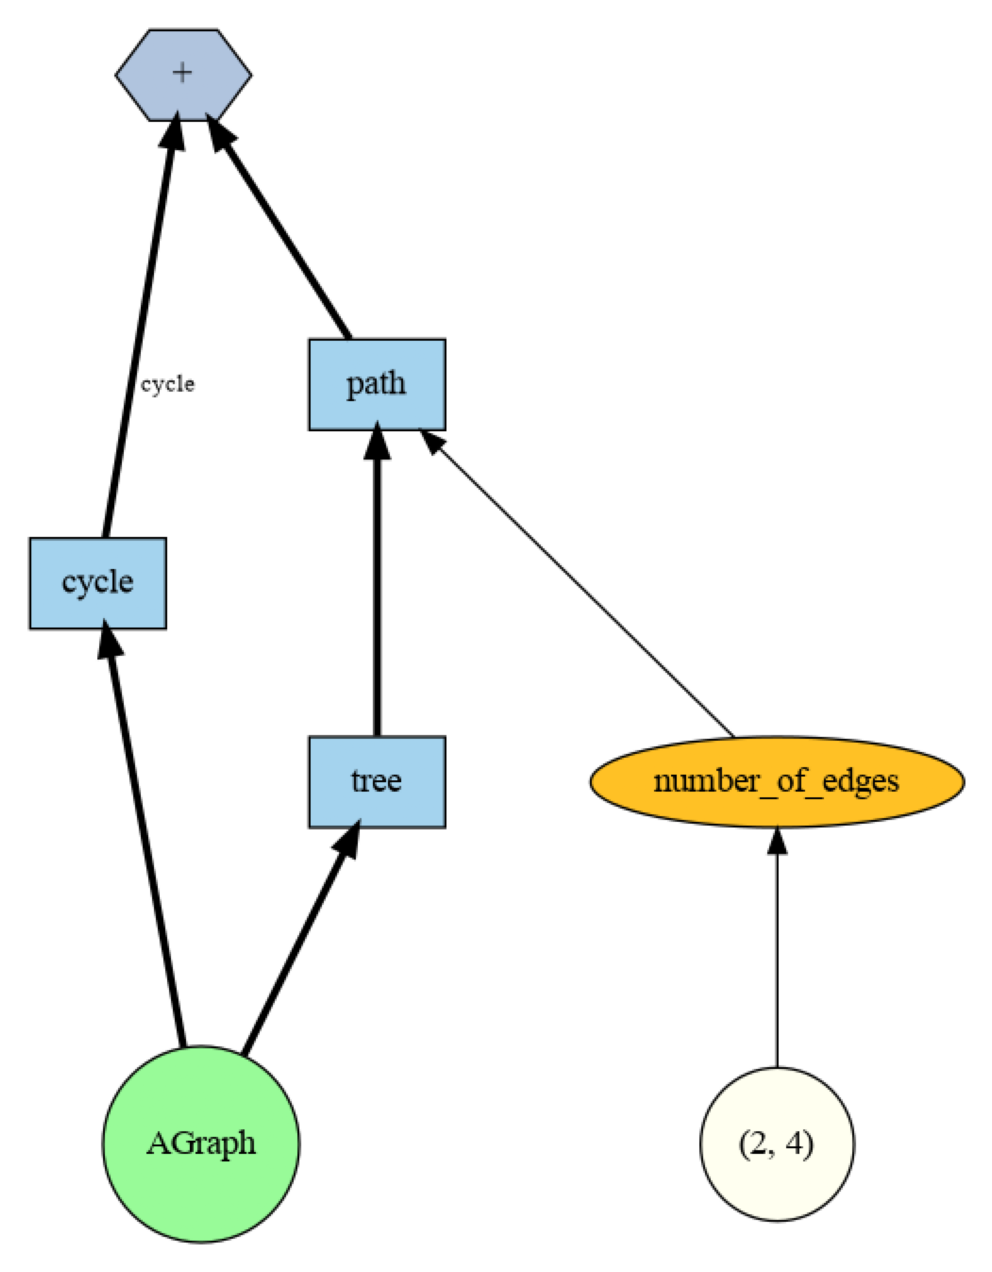

In [5]:
from abstractgraph.display import display_decomposition_graph
print('graph base decomposition')
display_decomposition_graph(df)

## Create estimator pipeline

Assemble the graph transformer and random-forest estimator wrapper.


In [6]:
from abstractgraph.vectorize import AbstractGraphTransformer
transformer = AbstractGraphTransformer(
    nbits=nbits,  # Hash width for interpretation-node feature ids.
    decomposition_function=df,  # Structural decomposition used to generate features.
    return_dense=True,  # Return a dense feature matrix instead of a sparse one.
    n_jobs=-1,  # Use all available CPU cores for vectorization.
)

from sklearn.ensemble import RandomForestClassifier
from abstractgraph_ml.estimators import GraphEstimator
graph_estimator = GraphEstimator(
    transformer=transformer,  # Converts graphs into structural feature vectors.
    estimator=RandomForestClassifier(random_state=0, n_estimators=300, n_jobs=-1),  # Downstream classifier and its hyperparameters.
    manifold=None,  # No additional manifold projection after vectorization.
    n_selected_features=500,  # Keep the top 500 features after fitting, if ranking is available.
)


## Train and evaluate

Split the dataset, fit the model, and report held-out performance.


In [7]:
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
import time

targets = np.array(targets)
n_instances = len(graphs)
graphs_tr, graphs_te, targets_tr, targets_te = train_test_split(
    graphs,  # Full graph list for this assay.
    targets,  # Binary activity labels aligned with graphs.
    test_size=0.2,  # Hold out 20% of the graphs for testing.
    random_state=0,  # Fixed seed for a reproducible split.
)
class_counts = dict(zip(*np.unique(targets, return_counts=True)))
print(f'assay_id:{assay_id}   #graphs:{n_instances}   #train:{len(graphs_tr)}   #test:{len(graphs_te)} (class_counts={class_counts})')

t_fit0 = time.perf_counter()
graph_estimator.fit(graphs_tr, targets_tr)
fit_time = time.perf_counter() - t_fit0

t_pred0 = time.perf_counter()
pred_te = graph_estimator.predict(graphs_te)
pred_time = time.perf_counter() - t_pred0
acc_te = accuracy_score(targets_te, pred_te)
errors_te = int((pred_te != targets_te).sum())
print(f'Test: accuracy={acc_te:.3f}, errors={errors_te}, fit_time={fit_time:.2f}s, pred_time={pred_time:.2f}s')

try:
    proba_te = graph_estimator.predict_proba(graphs_te)
    if proba_te.ndim == 2 and proba_te.shape[1] == 2:
        auc_te = roc_auc_score(targets_te, proba_te[:, 1])
        ap_te = average_precision_score(targets_te, proba_te[:, 1])
        print(f'Test: roc_auc={auc_te:.3f}, avg_precision={ap_te:.3f}')
except Exception:
    pass


assay_id:624249   #graphs:528   #train:422   #test:106 (class_counts={np.int64(0): np.int64(173), np.int64(1): np.int64(355)})
Test: accuracy=0.745, errors=27, fit_time=4.26s, pred_time=0.65s
Test: roc_auc=0.660, avg_precision=0.818


## Explain one prediction

Visualize node saliency for a single randomly selected test graph.


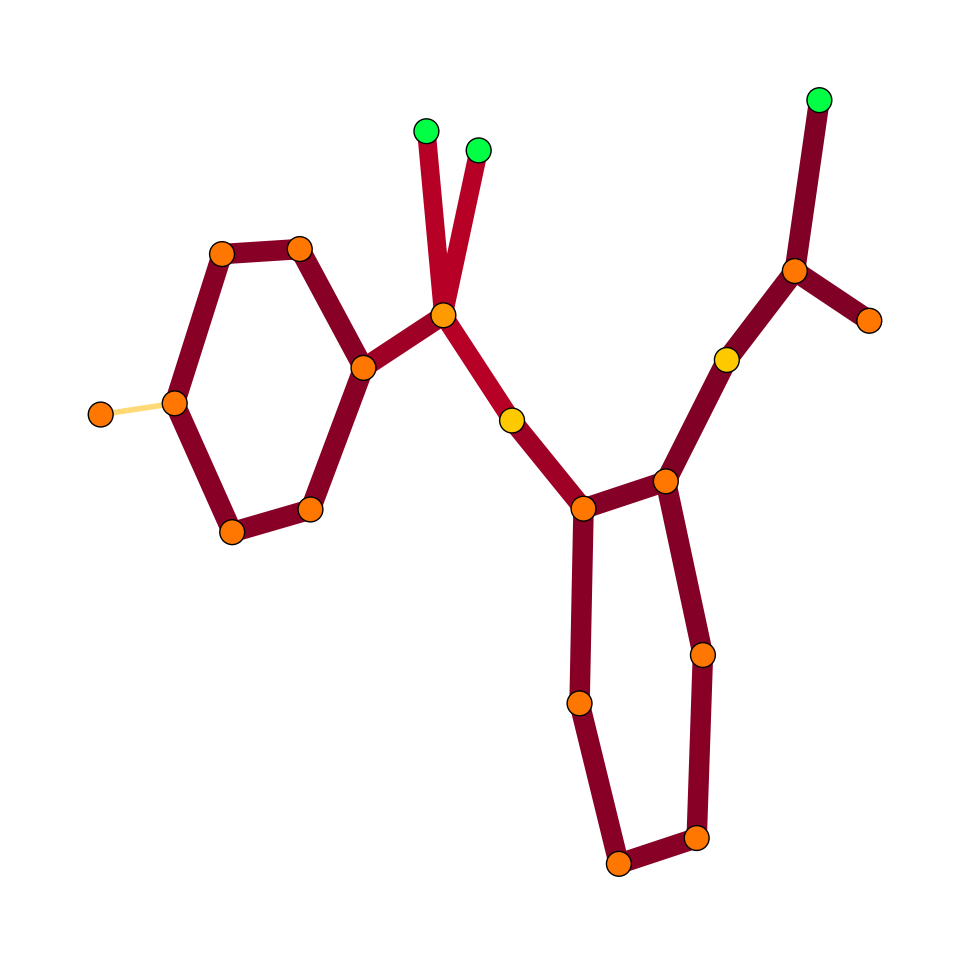

In [8]:
from abstractgraph_ml.importance import plot_graph_node_saliency_with_estimator
import random
_ = plot_graph_node_saliency_with_estimator(
    graphs_te[random.randrange(len(graphs_te))],  # One random held-out graph to explain.
    graph_estimator,  # Fitted estimator used to rank and map feature importance.
    node_agg="max",  # Use the strongest interpretation-node score touching each base node.
    edge_stat="mean",  # Set edge importance from the mean importance of its endpoint nodes.
    cmap="YlOrRd",  # Colormap used to encode saliency intensity.
    size=(6, 6),  # Figure size for the rendered explanation.
)


## Prepare class probabilities

Compute class probabilities and map each class label to its probability column.


In [9]:
# compute probabilities
proba_te = graph_estimator.predict_proba(graphs_te)
classes = graph_estimator.estimator_.classes_
class_to_col = {cls: i for i, cls in enumerate(classes)}

## Explain representative graphs

Sample high-confidence test graphs per class and plot saliency grids for comparison.


____________________________________________________________________________________________________________________________________________________________________________________


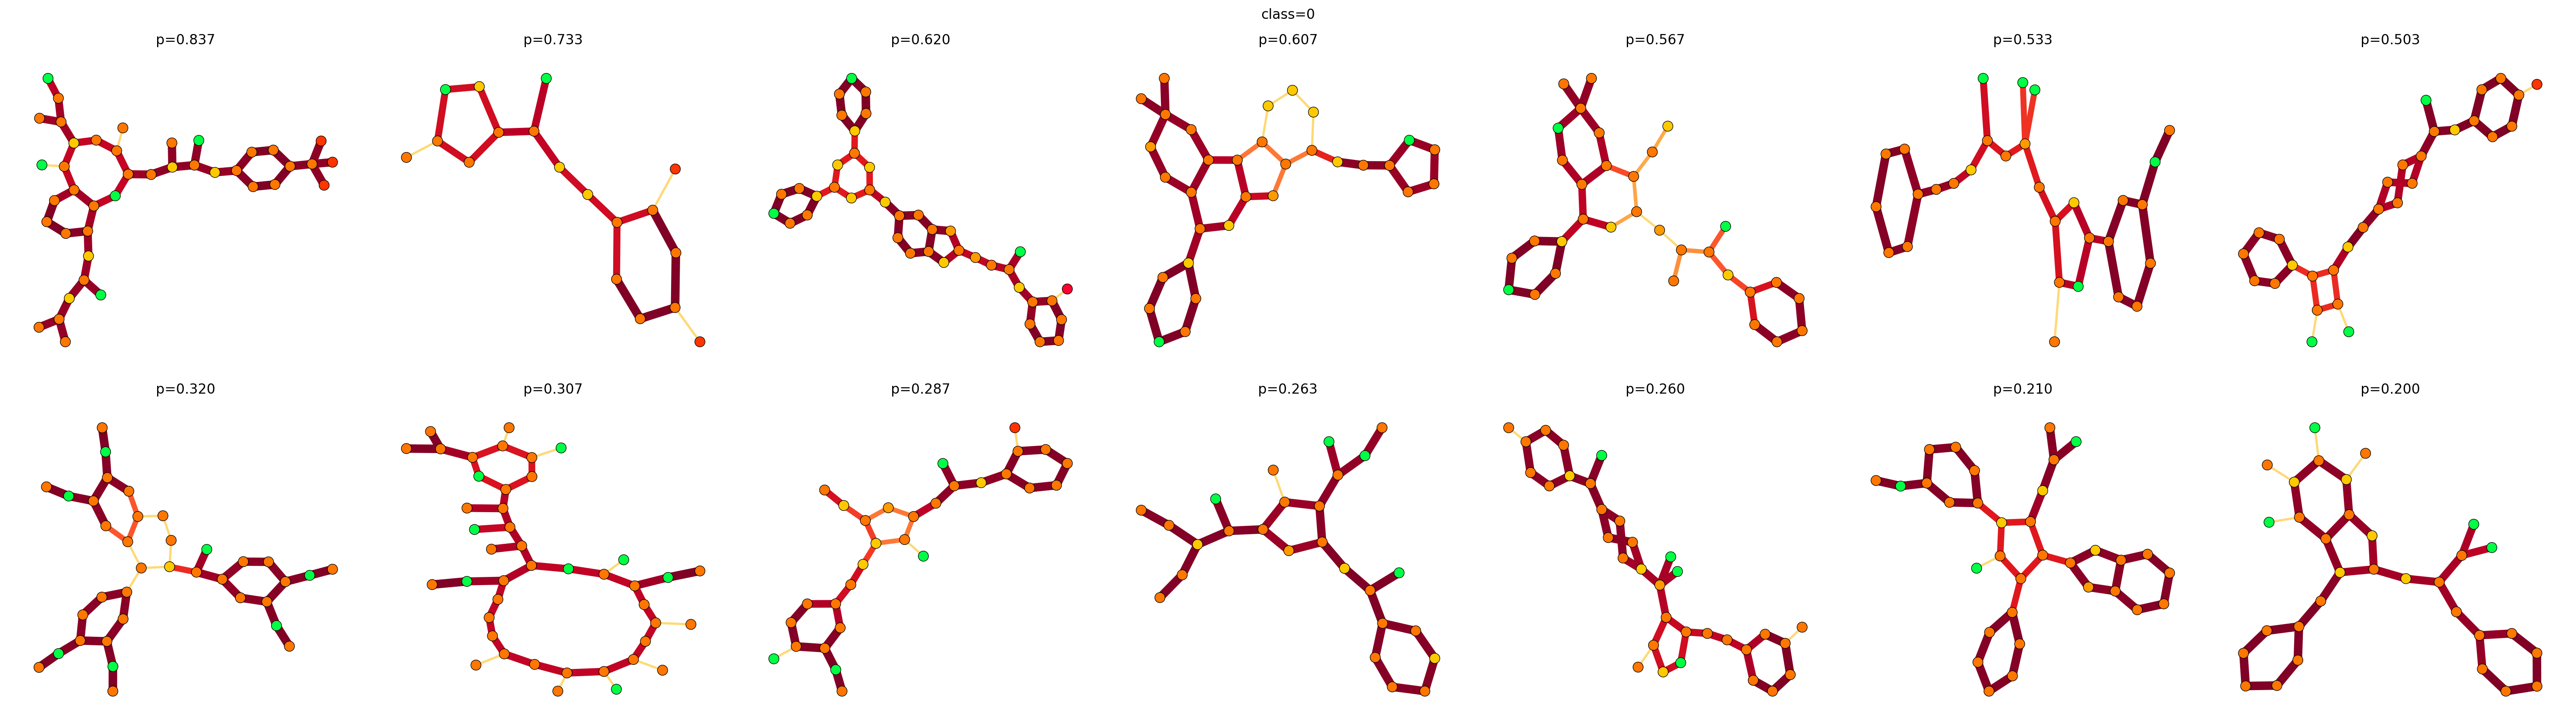

____________________________________________________________________________________________________________________________________________________________________________________


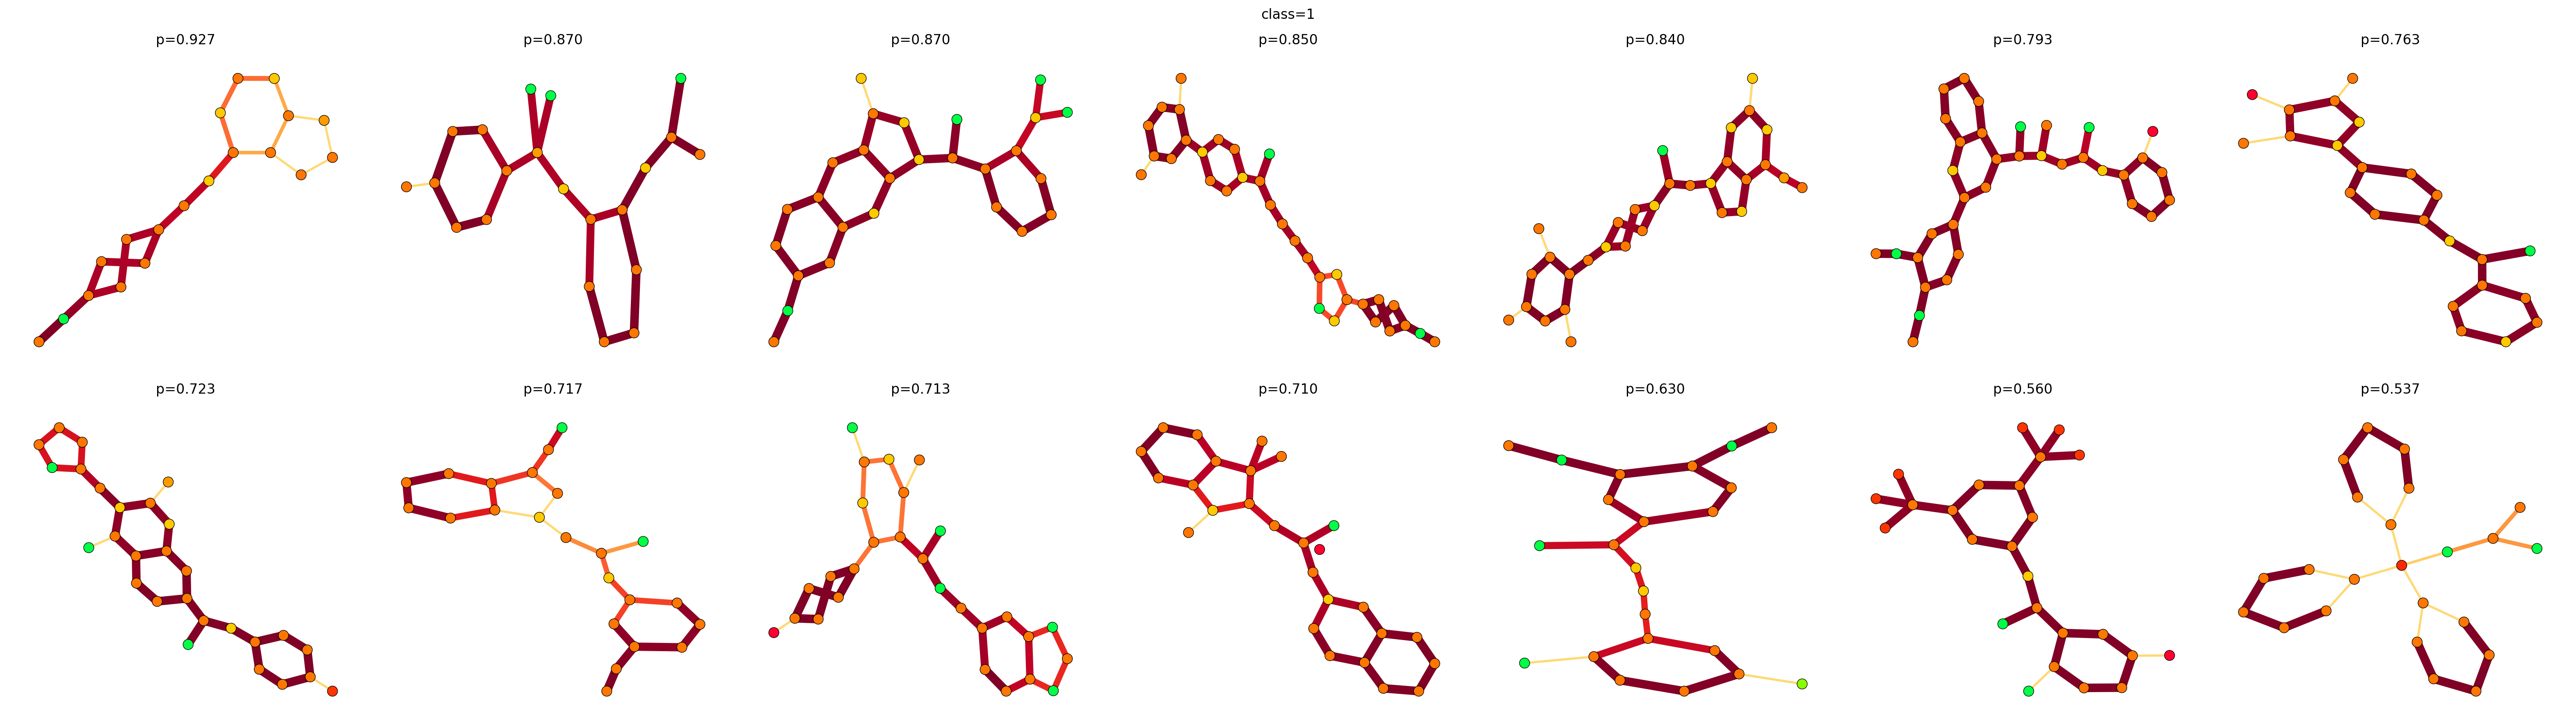

In [10]:
from abstractgraph_ml.importance import plot_graph_node_saliency_grid
# Select a random sample of n_show elements per class, weighted by class probability.
n_show = 14
n_elements_per_row = 7

selected = []
for cls in classes:
    idxs = np.where(targets_te == cls)[0]
    col = class_to_col[cls]
    p = proba_te[idxs, col]
    p = p / p.sum()
    size = min(n_show, idxs.size)
    top = np.random.choice(idxs, size=size, replace=False, p=p)
    top = top[np.argsort(-proba_te[top, col])]
    selected.append((cls, col, top))

# Plot the importance of each node/edge for a small set of representative graphs.
for cls, col, top in selected:
    print("_" * 180)
    titles = [f'p={proba_te[i, col]:.3f}' for i in top]
    sel_graphs = [graphs_te[i] for i in top]
    _ = plot_graph_node_saliency_grid(
        sel_graphs,  # Graphs to show in the explanation grid.
        graph_estimator=graph_estimator,  # Fitted estimator used to compute saliency.
        n_elements_per_row=n_elements_per_row,  # Number of graphs per row.
        suptitle=f'class={cls}',  # Figure title for the current class.
        titles=titles,  # Per-graph titles; here they show prediction probabilities.
        node_agg="mean",  # Average interpretation-node scores per base node.
        edge_stat="min",  # Use the weaker endpoint score for each edge.
        figsize_per_graph=(4.5, 4.5),  # Size allocated to each graph panel.
    )


---

## Inspect top-ranked feature subgraphs

Rank the fitted model's most important hashed interpretation-node labels and show representative mapped base subgraphs for each one.


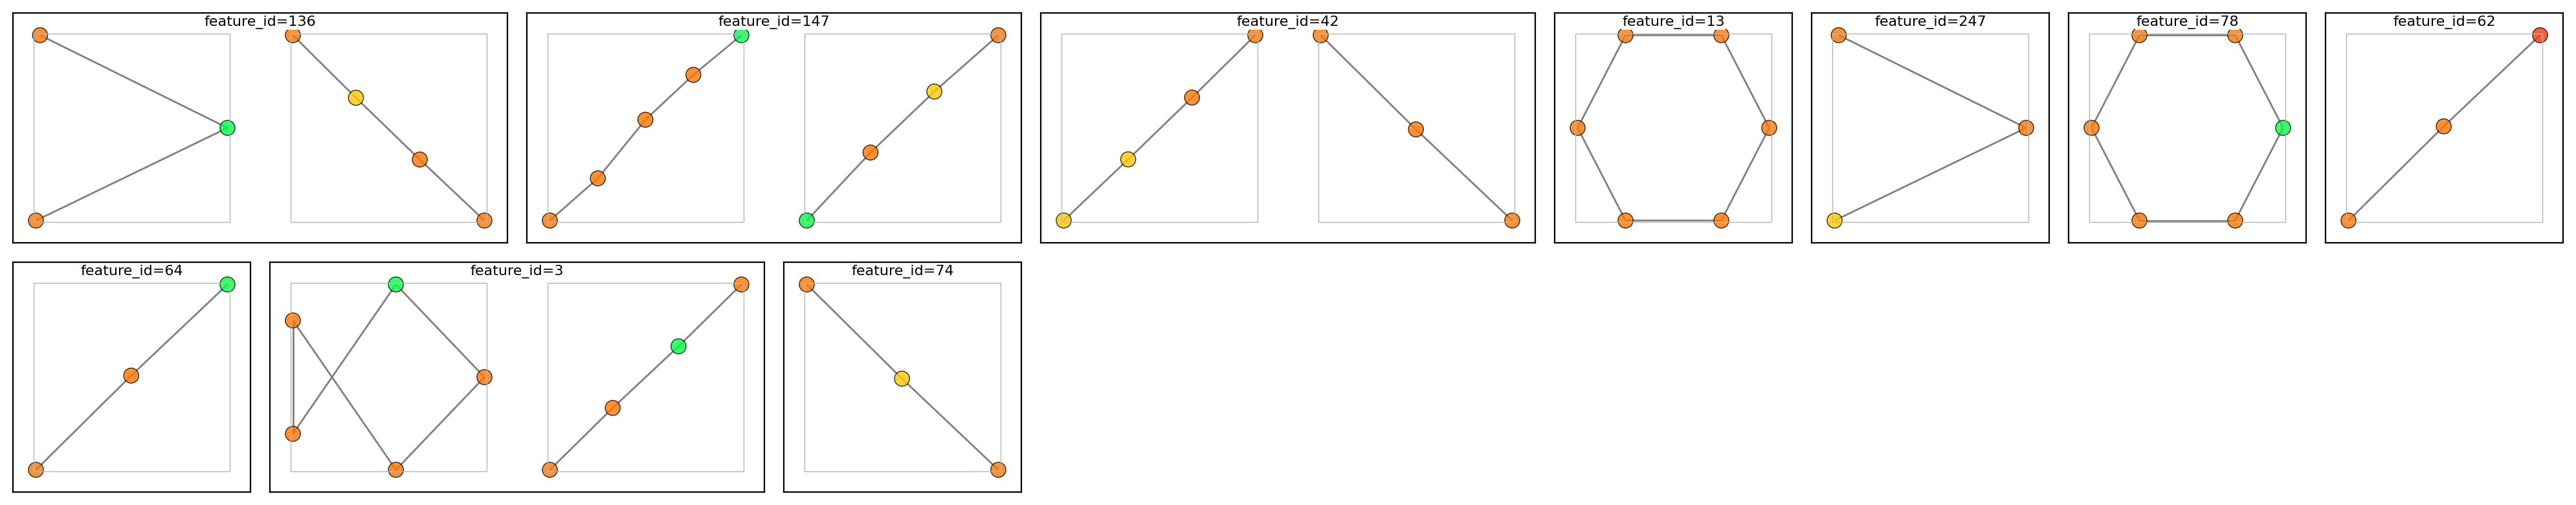

In [11]:
from abstractgraph_ml.importance import display_topk_feature_subgraphs

_ = display_topk_feature_subgraphs(
    graphs_tr,  # Training graphs used to recover subgraphs for important features.
    graph_estimator,  # Fitted estimator that provides the feature ranking.
    top_k_features=10,  # Number of top-ranked features to inspect.
    n_graphs_per_line=10,  # Number of subgraph cells per display row.
    size=(2.0, 2.0),  # Size of each subgraph cell in inches.
)
